# Transfer Learning com Bolsonaro × Lula — Notebook 3/4

## Aula: Aspectos Técnicos de CNNs em PyTorch — CDIA

### Por que esse dataset?

Treinar uma CNN do zero exige **milhares** de imagens. Aqui temos apenas **25 imagens por classe** (Bolsonaro e Lula) — é o cenário típico em projetos reais quando o dado é caro de rotular. **Transfer learning** é a técnica que faz essa quantidade pequena ser suficiente: reaproveitamos conhecimento de um modelo já treinado em milhões de imagens.

### O caminho pedagógico do notebook

Vamos seguir uma sequência que ilustra **por que o domínio do modelo pré-treinado importa**:

1. **Modo 1 — Feature extraction com `ResNet-18` (ImageNet):** congela tudo, troca só a `fc`. Funciona, mas a acurácia trava.
2. **Modo 2 — Fine-tuning de `ResNet-18`:** descongela `layer4` + `fc`, lr menor. Melhora.
3. **Modo 3 — `InceptionResnetV1` pré-treinada em `VGGFace2`:** mesmo método, mas o backbone já foi treinado em **rostos**. Resultado: salta dramaticamente.
4. **Pré-processamento com MTCNN:** detectar e cortar a face antes da CNN. Mais um salto na acurácia.
5. **Teste real:** classificar imagens "outras" (imagens que o modelo nunca viu) e medir desempenho.

### O que você vai praticar

- `torchvision.datasets.ImageFolder` com diretórios `train/<classe>/*.jpg`.
- Calcular `mean/std` empíricos do dataset.
- Substituir a `fc` final de uma rede pré-treinada por uma camada compatível com o número de classes.
- Congelar/descongelar parâmetros: `param.requires_grad = False`.
- Comparar **features genéricas (ImageNet)** vs **features específicas (VGGFace2)**.
- Usar `MTCNN` (`facenet-pytorch`) para detecção e crop de faces.
- Visualizar **pesos** de `conv1` e **feature maps** intermediários com hooks.

### Pré-requisitos

- Notebooks 1 e 2 desta aula.
- Saber o que é uma `ResNet` (camadas + skip connections).
- `pip install facenet-pytorch` para a parte 3 em diante.

## 1. Imports e configuração

A célula abaixo tenta instalar `facenet-pytorch` se ainda não estiver disponível. Se a instalação falhar (ambiente sem internet), as partes que usam `InceptionResnetV1` e `MTCNN` serão puladas.

In [1]:
# Garante facenet-pytorch (InceptionResnetV1 + MTCNN)
try:
    from facenet_pytorch import InceptionResnetV1, MTCNN  # noqa
    print("facenet-pytorch já instalado.")
    FACENET_OK = True
except ImportError:
    import subprocess, sys
    print("Instalando facenet-pytorch...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "facenet-pytorch"])
        from facenet_pytorch import InceptionResnetV1, MTCNN  # noqa
        FACENET_OK = True
    except Exception as e:
        print(f"Falha ao instalar facenet-pytorch: {e}")
        print("As seções de InceptionResnetV1/MTCNN serão puladas.")
        FACENET_OK = False

Instalando facenet-pytorch...


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      Traceback (most recent call last):
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_whe

Falha ao instalar facenet-pytorch: Command '['/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/bin/python', '-m', 'pip', 'install', '-q', 'facenet-pytorch']' returned non-zero exit status 1.
As seções de InceptionResnetV1/MTCNN serão puladas.


In [2]:
import os
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

# Reprodutibilidade
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def selecionar_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Nota: MPS (Apple Silicon) tem um bug em torch 2.7 com
    # adaptive_avg_pool2d que afeta a ResNet (#96056). Por isso forcamos
    # CPU aqui. O dataset eh pequeno (50 imgs), entao CPU eh aceitavel.
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print("MPS detectado, mas usando CPU por compatibilidade da ResNet.")
    return torch.device("cpu")

device = selecionar_device()
print(f"Device: {device}")
print(f"Torch: {torch.__version__} | Torchvision: {torchvision.__version__}")


MPS detectado, mas usando CPU por compatibilidade da ResNet.
Device: cpu
Torch: 2.12.0 | Torchvision: 0.27.0


## 2. Caminhos do dataset

O dataset `bolsolula/` já está organizado em três splits, cada um no formato `<split>/<classe>/<arquivo>` esperado pelo `ImageFolder`:

| Split | Conteúdo | Tamanho |
|-------|----------|---------|
| `train/` | imagens de treino, faces inteiras | 25 + 25 |
| `val/` | imagens de validação, faces inteiras | 25 + 25 |
| `outras/` | "teste no mundo real" — imagens completamente fora do treino | 3 + 3 |
| `train_cropped/`, `val_cropped/`, `outras_cropped/` | versões com **só a face** (já recortadas via MTCNN) | mesmas contagens |

Vamos usar `train/` e `val/` para os experimentos com `ResNet-18` (Modos 1 e 2), e depois `*_cropped/` para o `InceptionResnetV1` (Modo 3).

In [3]:
DATA_DIR = Path("../data/bolsolula")   # caminho relativo ao notebook
# fallback: se o notebook for executado da raiz do projeto
if not DATA_DIR.exists():
    DATA_DIR = Path("./data/bolsolula")
assert DATA_DIR.exists(), f"Dataset não encontrado em {DATA_DIR.resolve()}"

print(f"Dataset em: {DATA_DIR.resolve()}")
for split in ["train", "val", "outras", "train_cropped", "val_cropped", "outras_cropped"]:
    sub = DATA_DIR / split
    for cls in ["bolsonaro", "lula"]:
        n = len(list((sub / cls).glob("*.*")))
        print(f"  {split:20s}/{cls:10s}: {n:3d} imgs")

Dataset em: /Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/data/bolsolula
  train               /bolsonaro :  25 imgs
  train               /lula      :  25 imgs
  val                 /bolsonaro :  25 imgs
  val                 /lula      :  25 imgs
  outras              /bolsonaro :   3 imgs
  outras              /lula      :   3 imgs
  train_cropped       /bolsonaro :  25 imgs
  train_cropped       /lula      :  25 imgs
  val_cropped         /bolsonaro :  25 imgs
  val_cropped         /lula      :  25 imgs
  outras_cropped      /bolsonaro :   3 imgs
  outras_cropped      /lula      :   3 imgs


## 3. Exploração visual rápida

Vamos olhar **uma grade de exemplos** de cada classe. Quando o dataset é pequeno é especialmente importante inspecionar visualmente — descobre-se rapidamente problemas de qualidade, vazamento entre classes, fundo enviesado, etc.

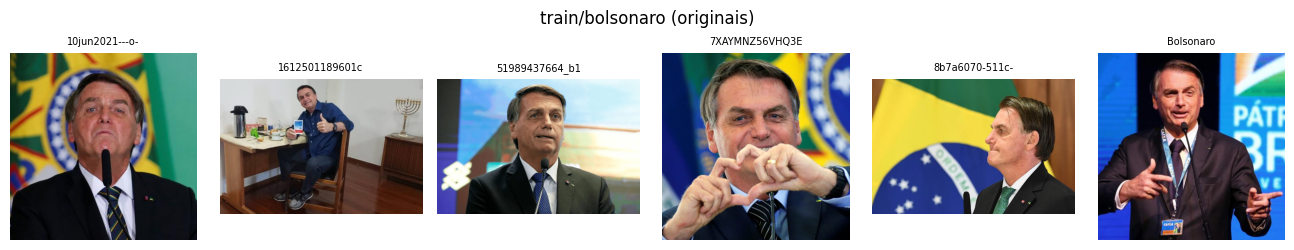

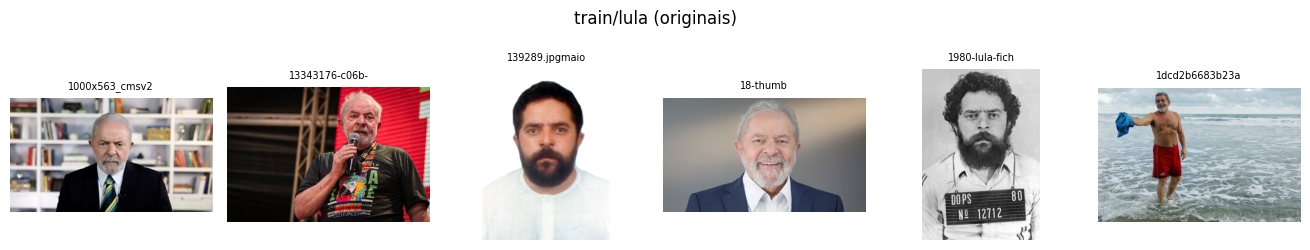

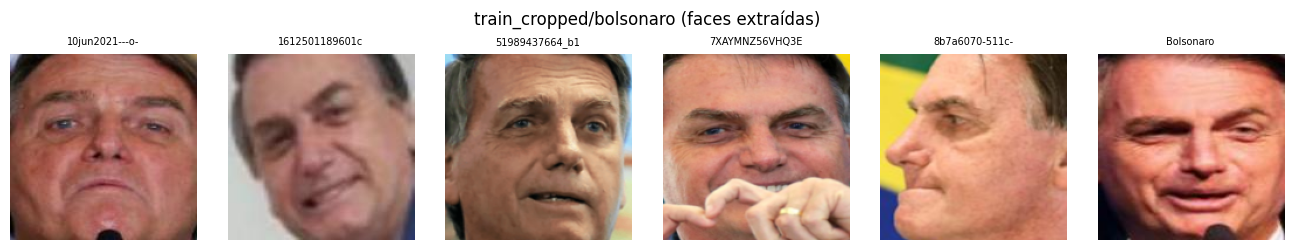

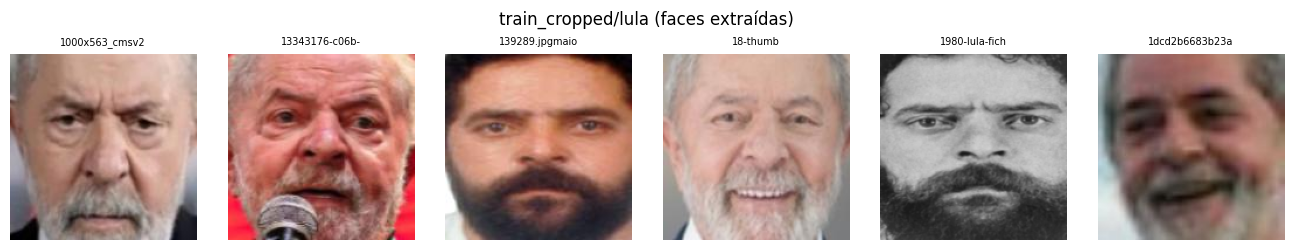

In [4]:
def grid_amostras(pasta, n=6, titulo=""):
    arquivos = sorted(pasta.glob("*.*"))[:n]
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.5))
    for ax, f in zip(axes, arquivos):
        ax.imshow(Image.open(f).convert("RGB")); ax.axis("off"); ax.set_title(f.stem[:14], fontsize=7)
    plt.suptitle(titulo); plt.tight_layout(); plt.show()

grid_amostras(DATA_DIR / "train" / "bolsonaro", titulo="train/bolsonaro (originais)")
grid_amostras(DATA_DIR / "train" / "lula",       titulo="train/lula (originais)")
grid_amostras(DATA_DIR / "train_cropped" / "bolsonaro", titulo="train_cropped/bolsonaro (faces extraídas)")
grid_amostras(DATA_DIR / "train_cropped" / "lula",       titulo="train_cropped/lula (faces extraídas)")

## 4. Estatísticas do dataset (mean / std)

Antes de definir os `transforms` é boa prática calcular **média e desvio-padrão** das imagens do treino. Isso permite normalizar de forma fiel ao próprio dataset — embora, para transfer learning com modelos pré-treinados, frequentemente seja mais correto usar as **estatísticas do dataset de origem** (ImageNet para a ResNet, VGGFace2 para o InceptionResnetV1).

Vamos calcular as duas e comparar.

In [5]:
def calcular_media_std(loader):
    '''Calcula mean/std canal a canal em um dataset de imagens [0,1].'''
    soma = torch.zeros(3); soma2 = torch.zeros(3); n_pixels = 0
    for X, _ in loader:
        # X: [N, 3, H, W]
        soma  += X.sum(dim=[0, 2, 3])
        soma2 += (X ** 2).sum(dim=[0, 2, 3])
        n_pixels += X.size(0) * X.size(2) * X.size(3)
    mean = soma / n_pixels
    var  = soma2 / n_pixels - mean ** 2
    std  = var.clamp(min=0).sqrt()
    return mean, std

ds_temp = datasets.ImageFolder(
    DATA_DIR / "train",
    transform=transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
)
mean_bolso, std_bolso = calcular_media_std(DataLoader(ds_temp, batch_size=8))
print(f"bolsolula/train (224x224) — média: {mean_bolso.numpy().round(4)}")
print(f"bolsolula/train (224x224) — std:   {std_bolso.numpy().round(4)}")

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225])
print(f"ImageNet            — média: {IMNET_MEAN.numpy()}")
print(f"ImageNet            — std:   {IMNET_STD.numpy()}")

bolsolula/train (224x224) — média: [0.4734 0.4415 0.4484]
bolsolula/train (224x224) — std:   [0.299  0.2827 0.2973]
ImageNet            — média: [0.485 0.456 0.406]
ImageNet            — std:   [0.229 0.224 0.225]


**Decisão:** vamos usar as estatísticas do **ImageNet** para os modos 1 e 2 (ResNet-18), porque é o que esses pesos esperam. Para o modo 3 (InceptionResnetV1/VGGFace2) usaremos as estatísticas próprias do dataset, mais coerentes com faces.

## 5. Datasets e DataLoaders

`RandomResizedCrop` + `RandomHorizontalFlip` + `RandomRotation` formam um data augmentation padrão para faces — variações naturais que não mudam a identidade.

In [6]:
BATCH = 16   # dataset pequeno; batch pequeno também

# === Transforms para ResNet-18 (modos 1 e 2) ===
transform_train = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN.tolist(), IMNET_STD.tolist()),
])
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN.tolist(), IMNET_STD.tolist()),
])

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=transform_train)
val_ds   = datasets.ImageFolder(DATA_DIR / "val",   transform=transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

CLASSES = train_ds.classes
print(f"Classes (idx → nome): {dict(enumerate(CLASSES))}")
print(f"Treino: {len(train_ds)} | Val: {len(val_ds)}")

Classes (idx → nome): {0: 'bolsonaro', 1: 'lula'}
Treino: 50 | Val: 50


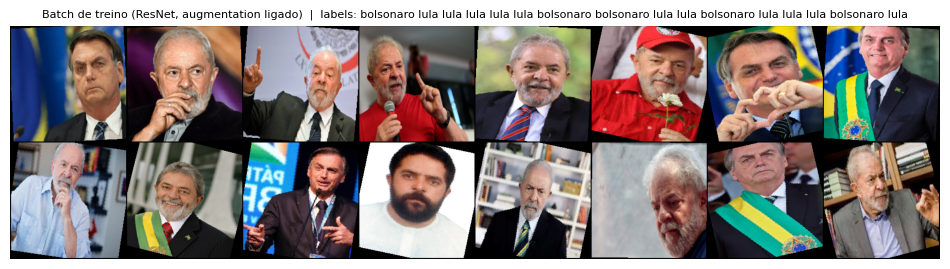

In [7]:
# Visualiza 1 batch já normalizado, desnormalizando para mostrar
def mostrar_batch(loader, mean, std, titulo=""):
    Xb, yb = next(iter(loader))
    Xb_vis = Xb * torch.tensor(std).view(1,3,1,1) + torch.tensor(mean).view(1,3,1,1)
    Xb_vis = Xb_vis.clamp(0, 1)
    grid = torchvision.utils.make_grid(Xb_vis, nrow=8, padding=2)
    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(titulo + "  |  labels: " + " ".join(CLASSES[i] for i in yb.tolist()), fontsize=8)
    plt.axis("off"); plt.show()

mostrar_batch(train_loader, IMNET_MEAN.tolist(), IMNET_STD.tolist(),
              titulo="Batch de treino (ResNet, augmentation ligado)")

## 6. Funções genéricas de treino / avaliação

Reaproveitáveis nos 3 modos. Note que o **otimizador** sempre filtra por `requires_grad` — assim só os parâmetros descongelados de fato recebem gradientes.

In [8]:
def treinar_epoca(model, loader, criterio, optimizer, device):
    model.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

@torch.no_grad()
def avaliar(model, loader, criterio, device):
    model.eval()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device); yb = yb.to(device)
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

def contar_treinaveis(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def treinar(model, n_epocas, optimizer, criterio, device, train_loader, val_loader, nome=""):
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()
    for ep in range(1, n_epocas + 1):
        tr_loss, tr_acc = treinar_epoca(model, train_loader, criterio, optimizer, device)
        vl_loss, vl_acc = avaliar(model, val_loader, criterio, device)
        hist['train_loss'].append(tr_loss); hist['val_loss'].append(vl_loss)
        hist['train_acc'].append(tr_acc);   hist['val_acc'].append(vl_acc)
        if ep == 1 or ep % 5 == 0 or ep == n_epocas:
            print(f"  [{nome}] ep {ep:3d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {vl_loss:.4f}/{vl_acc:.4f}")
    print(f"  [{nome}] Tempo total: {time.time()-t0:.1f}s")
    return hist

## 7. MODO 1 — Feature Extraction com ResNet-18 (ImageNet)

**Receita:**
1. Carrega `resnet18` com pesos do ImageNet.
2. `for p in model.parameters(): p.requires_grad = False` (congela tudo).
3. Substitui `model.fc` por uma `nn.Linear(512, 2)` — esta camada nova é a **única** treinável.

**Hipótese:** a ResNet aprendeu features genéricas (bordas, texturas, formas) suficientes para distinguir Bolsonaro e Lula? Vamos ver.

In [9]:
def setup_resnet_feature_extraction(num_classes=2):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.fc.in_features          # 512
    model.fc = nn.Linear(in_feats, num_classes)
    return model

modelo_fe = setup_resnet_feature_extraction().to(device)
print(f"Parâmetros totais:     {sum(p.numel() for p in modelo_fe.parameters()):,}")
print(f"Parâmetros treináveis: {contar_treinaveis(modelo_fe):,}")
# Apenas 512*2 + 2 = 1026 parâmetros treináveis!

Parâmetros totais:     11,177,538
Parâmetros treináveis: 1,026


In [10]:
criterio = nn.CrossEntropyLoss()
params_fe = [p for p in modelo_fe.parameters() if p.requires_grad]
optimizer = optim.SGD(params_fe, lr=1e-3, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Treinando MODO 1 — feature extraction (ResNet-18 / ImageNet)\n")
hist_fe = treinar(modelo_fe, n_epocas=8, optimizer=optimizer, criterio=criterio,
                  device=device, train_loader=train_loader, val_loader=val_loader,
                  nome="RESNET-FE")

Treinando MODO 1 — feature extraction (ResNet-18 / ImageNet)

  [RESNET-FE] ep   1 | train 0.7473/0.5000 | val 0.6824/0.5000
  [RESNET-FE] ep   5 | train 0.5181/0.7400 | val 0.5992/0.6400
  [RESNET-FE] ep   8 | train 0.4312/0.8000 | val 0.6265/0.6200
  [RESNET-FE] Tempo total: 27.2s


## 8. MODO 2 — Fine-tuning de ResNet-18 (descongelar `layer4`)

Mesmo modelo, mas agora `layer4` e a `fc` ficam treináveis. O resto continua congelado. Como os pesos de `layer4` já vêm bem treinados, usamos **lr menor** (1e-4) para não destruí-los.

In [11]:
def setup_resnet_fine_tuning(num_classes=2):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    # Descongela layer4 (última stage convolucional)
    for p in model.layer4.parameters():
        p.requires_grad = True
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

modelo_ft = setup_resnet_fine_tuning().to(device)
print(f"Parâmetros totais:     {sum(p.numel() for p in modelo_ft.parameters()):,}")
print(f"Parâmetros treináveis: {contar_treinaveis(modelo_ft):,}")

Parâmetros totais:     11,177,538
Parâmetros treináveis: 8,394,754


In [12]:
params_ft = [p for p in modelo_ft.parameters() if p.requires_grad]
optimizer = optim.SGD(params_ft, lr=1e-4, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Treinando MODO 2 — fine-tuning (ResNet-18 / ImageNet, layer4 + fc)\n")
hist_ft = treinar(modelo_ft, n_epocas=8, optimizer=optimizer, criterio=criterio,
                  device=device, train_loader=train_loader, val_loader=val_loader,
                  nome="RESNET-FT")

Treinando MODO 2 — fine-tuning (ResNet-18 / ImageNet, layer4 + fc)

  [RESNET-FT] ep   1 | train 0.7800/0.4600 | val 0.7382/0.5800
  [RESNET-FT] ep   5 | train 0.7162/0.5000 | val 0.7041/0.6000
  [RESNET-FT] ep   8 | train 0.6483/0.6200 | val 0.6522/0.6600
  [RESNET-FT] Tempo total: 26.8s


## 9. MODO 3 — `InceptionResnetV1` pré-treinada em VGGFace2

A ResNet do ImageNet "sabe" reconhecer objetos genéricos. Mas a tarefa real aqui é **reconhecer rostos**. Existe um backbone treinado para isso: o `InceptionResnetV1` treinado no **VGGFace2** (3.3 milhões de fotos de rostos de celebridades). Vamos usá-lo no lugar da ResNet.

**Decisão de design:**
- usamos as faces **já recortadas** (`train_cropped/`, `val_cropped/`) porque o `InceptionResnetV1` espera entrada de **rosto**, não da foto inteira;
- imagem 160×160 (input padrão do modelo);
- normalização com as estatísticas dos próprios crops.

In [13]:
if not FACENET_OK:
    print("facenet-pytorch indisponível — pulando modos 3 e 4.")
else:
    # Estatísticas do dataset de faces (160x160)
    ds_face_tmp = datasets.ImageFolder(
        DATA_DIR / "train_cropped",
        transform=transforms.Compose([transforms.Resize((160, 160)), transforms.ToTensor()])
    )
    mean_face, std_face = calcular_media_std(DataLoader(ds_face_tmp, batch_size=8))
    print(f"train_cropped (160x160) — média: {mean_face.numpy().round(4)}")
    print(f"train_cropped (160x160) — std:   {std_face.numpy().round(4)}")

facenet-pytorch indisponível — pulando modos 3 e 4.


In [14]:
if FACENET_OK:
    transform_face_train = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean_face.tolist(), std_face.tolist()),
    ])
    transform_face_eval = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean_face.tolist(), std_face.tolist()),
    ])

    train_face_ds = datasets.ImageFolder(DATA_DIR / "train_cropped", transform=transform_face_train)
    val_face_ds   = datasets.ImageFolder(DATA_DIR / "val_cropped",   transform=transform_face_eval)
    train_face_loader = DataLoader(train_face_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
    val_face_loader   = DataLoader(val_face_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

    print(f"Treino (faces): {len(train_face_ds)} | Val (faces): {len(val_face_ds)}")

In [15]:
if FACENET_OK:
    # InceptionResnetV1 com num_classes=2: ele já configura a 'logits' final automaticamente
    modelo_face = InceptionResnetV1(pretrained='vggface2', classify=True, num_classes=2)

    # Feature extraction: congela todo o backbone, treina só 'logits'
    for p in modelo_face.parameters():
        p.requires_grad = False
    for p in modelo_face.logits.parameters():
        p.requires_grad = True

    modelo_face = modelo_face.to(device)
    print(f"Parâmetros totais:     {sum(p.numel() for p in modelo_face.parameters()):,}")
    print(f"Parâmetros treináveis: {contar_treinaveis(modelo_face):,}")

In [16]:
if FACENET_OK:
    params_face = [p for p in modelo_face.parameters() if p.requires_grad]
    optimizer = optim.SGD(params_face, lr=1e-3, momentum=0.9)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    print("Treinando MODO 3 — InceptionResnetV1 (VGGFace2) / faces cropped\n")
    hist_face = treinar(modelo_face, n_epocas=8, optimizer=optimizer, criterio=criterio,
                        device=device, train_loader=train_face_loader, val_loader=val_face_loader,
                        nome="FACENET-FE")

## 10. Comparativo: os três modos lado a lado

Resposta esperada: o **modo 3** salta para acurácia perto de 100% mesmo com 25 imagens por classe, porque o backbone já entende faces. Os modos 1 e 2 (ResNet/ImageNet) ficam claramente abaixo.

> **Mensagem central:** o backbone certo é o que enxerga o problema certo. Transfer learning não é só "usar um modelo grande" — é escolher o modelo cuja **representação interna** é próxima do seu domínio.

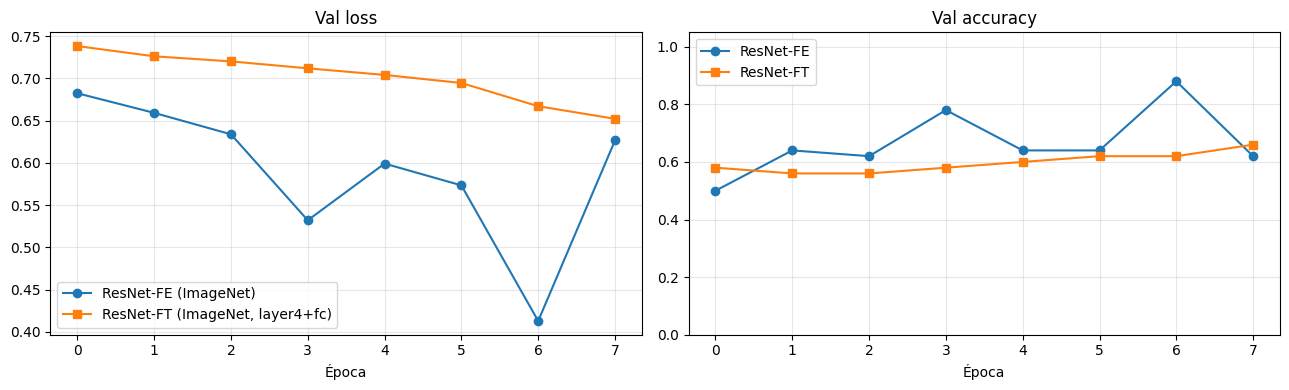


Modo                                  Treináveis Val Acc final
------------------------------------------------------------
1. ResNet-FE (ImageNet)                    1,026       0.6200
2. ResNet-FT (ImageNet, layer4+fc)     8,394,754       0.6600


In [17]:
def plot_comparativo():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(hist_fe['val_loss'],  'o-', label='ResNet-FE (ImageNet)')
    axes[0].plot(hist_ft['val_loss'],  's-', label='ResNet-FT (ImageNet, layer4+fc)')
    if FACENET_OK:
        axes[0].plot(hist_face['val_loss'], '^-', label='InceptionResnetV1 (VGGFace2)')
    axes[0].set_title('Val loss'); axes[0].set_xlabel('Época'); axes[0].grid(alpha=0.3); axes[0].legend()

    axes[1].plot(hist_fe['val_acc'],  'o-', label='ResNet-FE')
    axes[1].plot(hist_ft['val_acc'],  's-', label='ResNet-FT')
    if FACENET_OK:
        axes[1].plot(hist_face['val_acc'], '^-', label='InceptionResnetV1 (VGGFace2)')
    axes[1].set_title('Val accuracy'); axes[1].set_xlabel('Época'); axes[1].grid(alpha=0.3); axes[1].legend()
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout(); plt.show()

plot_comparativo()

print("\n" + "=" * 60)
print(f"{'Modo':<35} {'Treináveis':>12} {'Val Acc final':>12}")
print("-" * 60)
print(f"{'1. ResNet-FE (ImageNet)':<35} {contar_treinaveis(modelo_fe):>12,} {hist_fe['val_acc'][-1]:>12.4f}")
print(f"{'2. ResNet-FT (ImageNet, layer4+fc)':<35} {contar_treinaveis(modelo_ft):>12,} {hist_ft['val_acc'][-1]:>12.4f}")
if FACENET_OK:
    print(f"{'3. InceptionResnetV1 (VGGFace2)':<35} {contar_treinaveis(modelo_face):>12,} {hist_face['val_acc'][-1]:>12.4f}")
print("=" * 60)

## 11. Testando no `outras/` — "mundo real"

Validação está bem, mas as imagens de validação são "parecidas" com as de treino (mesma fonte, mesmo enquadramento). O verdadeiro teste são as imagens em `outras/`, que **nunca entraram em nenhum treino**. Vamos rodar inferência nelas usando o melhor modelo (modo 3).

In [18]:
if FACENET_OK:
    outras_ds = datasets.ImageFolder(DATA_DIR / "outras_cropped", transform=transform_face_eval)
    outras_loader = DataLoader(outras_ds, batch_size=8, shuffle=False)

    modelo_face.eval()
    Xb, yb = next(iter(outras_loader))
    Xb = Xb.to(device)
    with torch.no_grad():
        logits = modelo_face(Xb)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1).cpu()
        probs  = probs.cpu()

    # Visualiza com pred vs label
    n = Xb.size(0)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = np.array(axes).reshape(rows, cols)
    Xb_vis = Xb.cpu() * std_face.view(1,3,1,1) + mean_face.view(1,3,1,1)
    Xb_vis = Xb_vis.clamp(0, 1)
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off"); continue
        ax.imshow(Xb_vis[i].permute(1, 2, 0).numpy())
        verdade = CLASSES[yb[i].item()]
        pred    = CLASSES[preds[i].item()]
        prob    = probs[i, preds[i]].item() * 100
        cor = "green" if pred == verdade else "red"
        ax.set_title(f"{pred} ({prob:.1f}%)\nGT: {verdade}", fontsize=8, color=cor)
        ax.axis("off")
    plt.tight_layout(); plt.show()

    acc_outras = (preds == yb).float().mean().item()
    print(f"\nAcurácia em 'outras_cropped': {acc_outras:.4f} ({(preds==yb).sum().item()}/{len(yb)})")

## 12. MTCNN: como as faces foram extraídas

O dataset já vinha com a pasta `*_cropped/`. Mas como foi feita essa extração?

O MTCNN (`facenet-pytorch`) detecta faces e devolve um crop alinhado. O bloco abaixo é um **exemplo demonstrativo** mostrando o passo: pegar uma imagem inteira de `outras/`, detectar a face com MTCNN, salvar/retornar o crop.

Você normalmente roda isso **uma vez** para gerar a pasta `*_cropped/`, e depois treina sobre os crops.

In [19]:
if FACENET_OK:
    mtcnn = MTCNN(
        image_size=160, margin=0, min_face_size=20,
        thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
        device=device
    )

    # Exemplo: pega 4 imagens de outras/ e mostra antes vs depois do MTCNN
    exemplos = []
    for cls in ["bolsonaro", "lula"]:
        for f in sorted((DATA_DIR / "outras" / cls).glob("*.*"))[:2]:
            exemplos.append((cls, f))

    fig, axes = plt.subplots(2, len(exemplos), figsize=(len(exemplos) * 2.5, 5.2))
    for j, (cls, f) in enumerate(exemplos):
        img = Image.open(f).convert("RGB")
        axes[0, j].imshow(img); axes[0, j].set_title(f"original\n{cls}", fontsize=8); axes[0, j].axis("off")

        face_tensor = mtcnn(img)   # tensor [3, 160, 160] já normalizado por post_process
        if face_tensor is not None:
            face_vis = (face_tensor + 1) / 2     # MTCNN devolve em [-1, 1]
            face_vis = face_vis.clamp(0, 1)
            axes[1, j].imshow(face_vis.permute(1, 2, 0).cpu().numpy())
            axes[1, j].set_title("face MTCNN", fontsize=8)
        else:
            axes[1, j].text(0.5, 0.5, "face\nnão detectada", ha="center", va="center")
        axes[1, j].axis("off")

    plt.tight_layout(); plt.show()

## 13. Visualizando os PESOS de `conv1` da ResNet-18

Já que treinamos uma ResNet por aqui, vamos olhar o que o **filtro inicial** dela aprendeu — esses pesos vêm do treino em ImageNet e não foram tocados. Cada filtro tem shape `[3, 7, 7]` (3 canais RGB) e pode ser visualizado como uma imagem colorida pequena.

> **Cuidado conceitual:** estes são **filtros (pesos)**, não **feature maps (saídas)**. Confundir os dois é um erro clássico — vamos ver o feature map na próxima seção.

Shape de conv1.weight: (64, 3, 7, 7)  # [64 saídas, 3 canais, K=7, K=7]


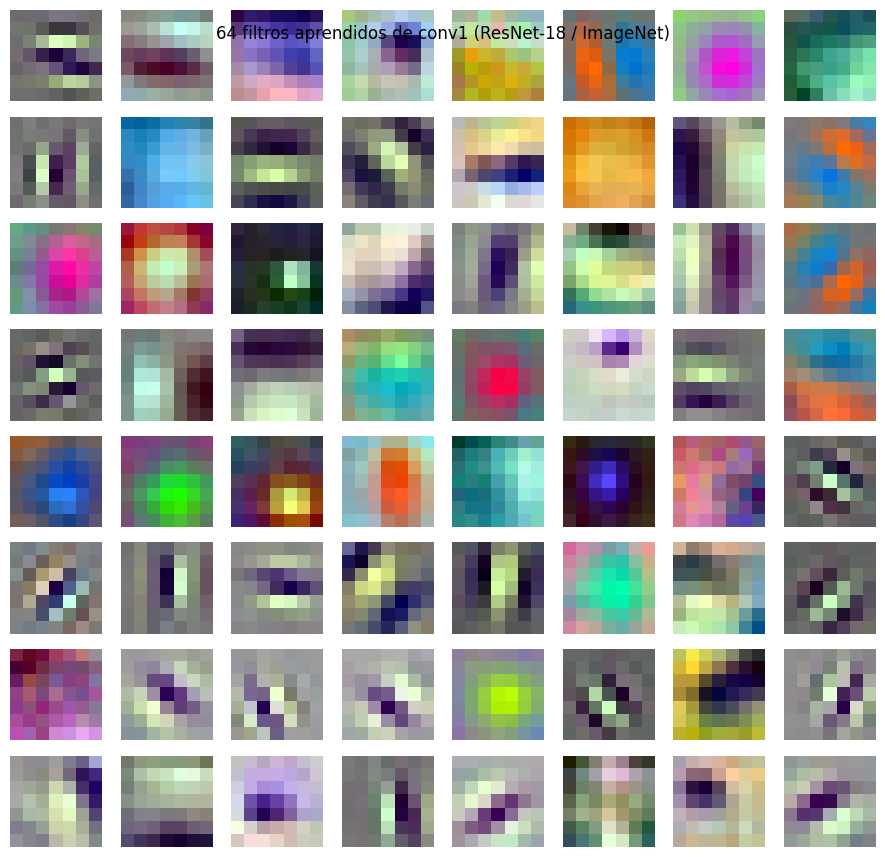

In [20]:
resnet_orig = models.resnet18(weights=ResNet18_Weights.DEFAULT).to(device).eval()

filtros = resnet_orig.conv1.weight.detach().cpu()
print(f"Shape de conv1.weight: {tuple(filtros.shape)}  # [64 saídas, 3 canais, K=7, K=7]")

fmin = filtros.amin(dim=(1,2,3), keepdim=True)
fmax = filtros.amax(dim=(1,2,3), keepdim=True)
filtros_norm = (filtros - fmin) / (fmax - fmin + 1e-9)

fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(filtros_norm[i].permute(1, 2, 0).numpy()); ax.axis("off")
plt.suptitle('64 filtros aprendidos de conv1 (ResNet-18 / ImageNet)', y=0.93)
plt.tight_layout(); plt.show()

## 14. Visualizando feature maps com `forward_hook`

`register_forward_hook` adiciona um callback à camada — toda vez que ela é executada, capturamos a saída. Aqui pegamos a ativação de `layer1[0].conv1` quando passamos a primeira imagem de Bolsonaro do val.

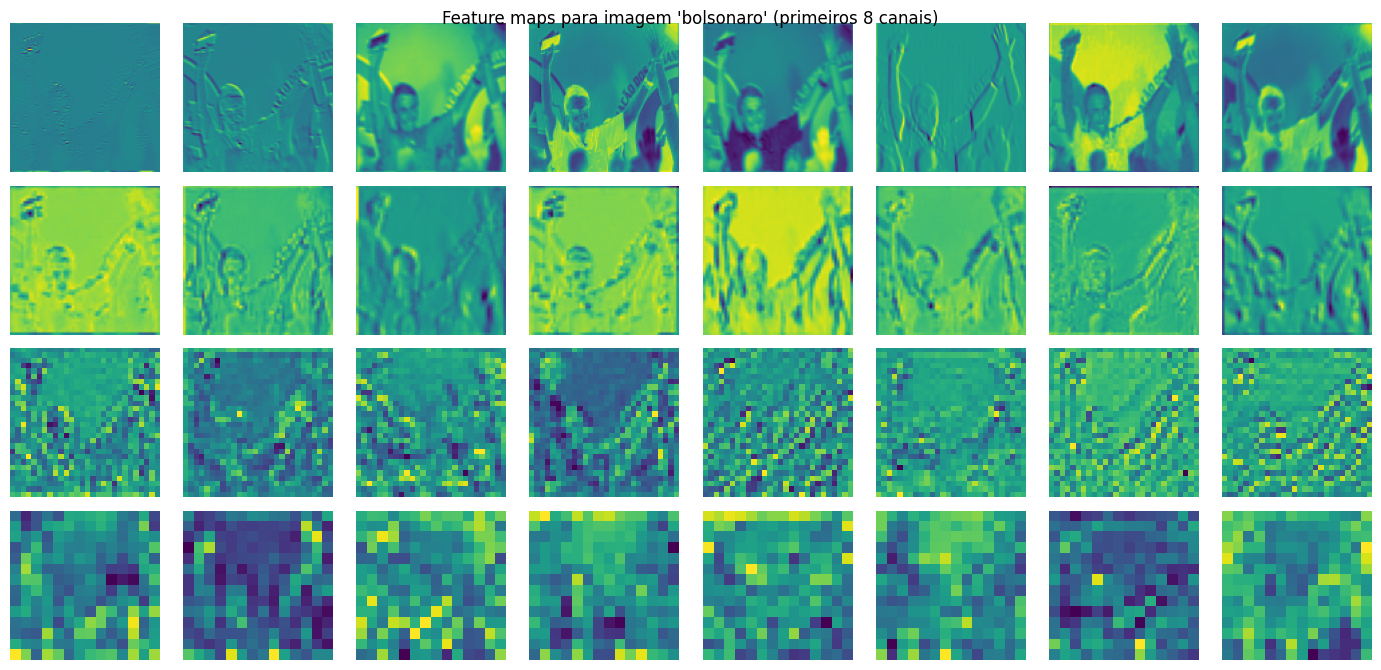

In [21]:
# Imagem de exemplo (val/bolsonaro/...)
val_loader_one = DataLoader(val_ds, batch_size=1, shuffle=False)
img_t, lbl_t = next(iter(val_loader_one))
img_t = img_t.to(device)

# Storage do hook
ativacoes = {}
def hook(nome):
    def _f(modulo, inp, out):
        ativacoes[nome] = out.detach().cpu()
    return _f

handles = [
    resnet_orig.conv1.register_forward_hook(hook('conv1')),
    resnet_orig.layer1[0].conv1.register_forward_hook(hook('layer1_0_conv1')),
    resnet_orig.layer2[0].conv1.register_forward_hook(hook('layer2_0_conv1')),
    resnet_orig.layer3[0].conv1.register_forward_hook(hook('layer3_0_conv1')),
]
with torch.no_grad():
    _ = resnet_orig(img_t)
for h in handles: h.remove()

# Plot: 8 canais de cada camada capturada
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
nomes = list(ativacoes.keys())
for r, nome in enumerate(nomes):
    fmap = ativacoes[nome][0]   # [C, H, W]
    for c in range(8):
        axes[r, c].imshow(fmap[c].numpy(), cmap='viridis'); axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(nome, rotation=0, ha="right", va="center", fontsize=8)
plt.suptitle(f"Feature maps para imagem '{CLASSES[lbl_t.item()]}' (primeiros 8 canais)", y=0.95)
plt.tight_layout(); plt.show()

## Resumo e próximos passos

Você praticou três estratégias de transfer learning com o dataset **bolsolula**:

| # | Estratégia | Backbone | Treinável | Esperado em val |
|---|------------|----------|-----------|-----------------|
| 1 | Feature extraction | ResNet-18 (ImageNet) | ~1k | médio |
| 2 | Fine-tuning `layer4+fc` | ResNet-18 (ImageNet) | ~5M | melhor |
| 3 | Feature extraction | InceptionResnetV1 (VGGFace2) | ~3k | quase 100% |

**Lições centrais:**

- Com dataset pequeno (~50 imagens), **transfer learning é praticamente obrigatório** — treinar do zero é inviável.
- O **domínio do pré-treino** importa muito: features de faces (VGGFace2) batem features genéricas (ImageNet) numa tarefa de faces.
- **Cortar a face** com MTCNN antes de classificar é outro ganho — remove o ruído de fundo.
- A separação **pesos vs feature maps** é fundamental para entender o que está acontecendo dentro da rede.

### Próximo notebook

`04_visualizacao_e_debug.ipynb` — Ferramentas técnicas: hooks múltiplos, **Grad-CAM**, **mixed precision** (`autocast`), persistência correta de `state_dict`, **TorchScript**, reprodutibilidade total e benchmarking de `num_workers`.